# Analisis Data Awal: NYC Airbnb 2019

Notebook ini disusun dengan bahasa yang disederhanakan:

1. Analisis Data Awal = mengenali data sebelum membuat prediksi.
2. Tujuan = mengubah data mentah yang membingungkan menjadi fakta yang berguna.
3. Penghematan Memori = pilih kolom yang penting saja dan saring data tidak masuk akal di awal agar komputer tidak lemot.
4. Visual bukan hiasan: setiap grafik wajib menjawab pertanyaan bisnis.
5. Memastikan Keterwakilan Data: pastikan sebagian data yang diambil (sampel) mewakili seluruh populasi.
6. Tulis batasan analisis dan saran yang masuk akal.

**Pertanyaan pendukung sebelum membuat grafik:**

> Grafik ini dibuat untuk menjawab keputusan apa, dan tindakan apa yang berubah jika polanya berbeda?

---
### Kamus Data (Penjelasan Kolom)
- **`id`**: ID unik untuk setiap properti.
- **`host_id`**: Identitas dari sang pemilik properti.
- **`neighbourhood_group`**: Wilayah besar / Kabupaten (seperti Manhattan, Brooklyn).
- **`neighbourhood`**: Area spesifik / Kelurahan di dalam wilayah besar tersebut.
- **`latitude` / `longitude`**: Koordinat peta lokasi properti.
- **`room_type`**: Tipe properti (Apakah penyewa menyewa seluruh rumah/apartemen, atau hanya satu kamar saja?).
- **`price`**: Harga sewa per malam (dalam dolar).
- **`minimum_nights`**: Syarat minimal menginap (membantu membedakan penyewa harian vs jangka panjang).
- **`number_of_reviews`**: Berapa kali properti ini pernah diulas (menunjukkan seberapa sering disewa).
- **`last_review`**: Tanggal ulasan terakhir diberikan.
- **`reviews_per_month`**: Rata-rata ulasan yang masuk tiap bulan (indikator tingkat kelarisan properti).
- **`calculated_host_listings_count`**: Jumlah properti yang dimiliki oleh satu pemilik yang sama (menandakan host perorangan vs juragan properti).
- **`availability_365`**: Ketersediaan properti sepanjang tahun atau 365 hari (angka rendah berarti tempat ini sering penuh dipesan).

In [1]:
import warnings
!pip install kagglehub
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

# Download latest version
dataset_handle = "dgomonov/new-york-city-airbnb-open-data"
path = kagglehub.dataset_download(dataset_handle)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [2]:
# Langkah penghematan 1: Ambil informasi yang digunakan saja
selected_cols = [
    "id",
    "host_id",
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "last_review",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

# last_review diparse saat load untuk efisiensi langkah berikutnya
df_raw = pd.read_csv(
    f"{path}/AB_NYC_2019.csv",
    usecols=selected_cols,
    parse_dates=["last_review"],
)

# Langkah penghematan 2: Buang data yang tidak masuk akal (harga 0, koordinat di luar wilayah) sejak awal
mask_valid = (
    (df_raw["price"] > 0)
    & (df_raw["availability_365"].between(0, 365))
    & (df_raw["latitude"].between(40.45, 40.95))
    & (df_raw["longitude"].between(-74.30, -73.65))
)

df = df_raw.loc[mask_valid].copy()

print(f"Baris awal (keseluruhan): {len(df_raw):,}")
print(f"Baris setelah pembersihan data rusak: {len(df):,}")
print(f"Baris terbuang: {len(df_raw) - len(df):,}")

df.head(5)

Baris awal (keseluruhan): 48,895
Baris setelah pembersihan data rusak: 48,884
Baris terbuang: 11


,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
def fmt_num(x, digits=2):
    if pd.isna(x):
        return "NA"
    if abs(x) >= 1000:
        return f"{x:,.{digits}f}"
    return f"{x:.{digits}f}"


def ask_plot(question):
    display(Markdown(f"**Pertanyaan grafik:** {question}"))


def explain_plot(points):
    bullet_text = "\n".join([f"- {p}" for p in points])
    display(Markdown(f"**Interpretasi :**\n{bullet_text}"))


def section(title):
    display(Markdown(f"## {title}"))

## Langkah 1: Pemeriksaan Awal dan Kelengkapan Data

,indikator,nilai
0,jumlah_baris,48884
1,jumlah_kolom,14
2,duplikasi_baris,0


### Tabel Bagian Data yang Kosong (Missing Value)

,missing_count,missing_pct
last_review,10051,20.56092
reviews_per_month,10051,20.56092
neighbourhood_group,0,0.00000
neighbourhood,0,0.00000
id,0,0.00000
host_id,0,0.00000
longitude,0,0.00000
latitude,0,0.00000
room_type,0,0.00000
price,0,0.00000


### Tabel Jumlah Variasi Kategori Data

,kolom_kategorikal,jumlah_kategori_unik
0,neighbourhood_group,5
1,neighbourhood,221
2,room_type,3


**Pertanyaan grafik:** Informasi mana yang paling banyak kosong, dan adakah alasannya?

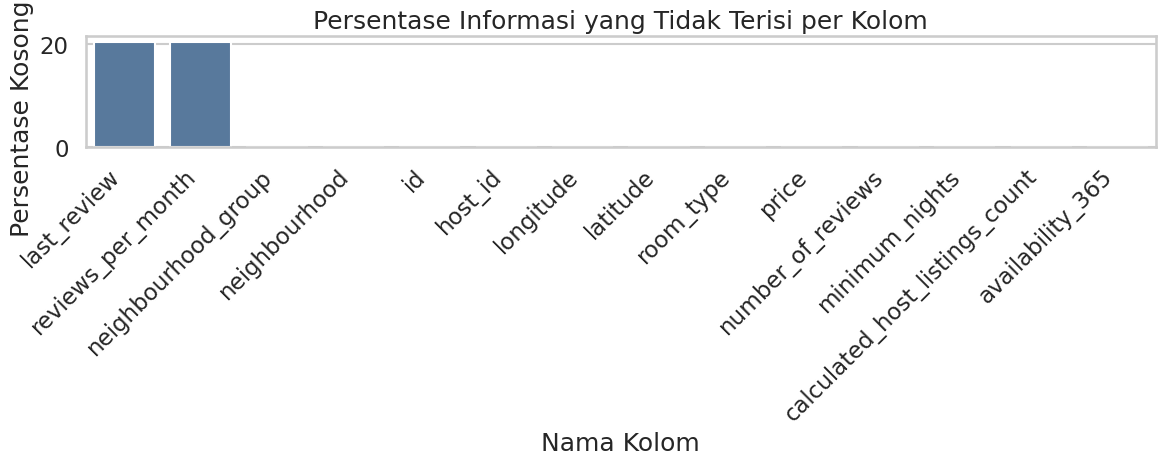

**Interpretasi :**
- Dua informasi yang paling sering kosong adalah ulasan terakhir (20.56%) dan rata-rata ulasan per bulan (20.56%).
- Menariknya, 100.00% dari data yang kosong di dua tempat ini selalu terjadi bersamaan. Ini menandakan **properti tersebut memang belum pernah mendapat pesanan/ulasan**.
- Artinya sifat kosong ini bukan karena datanya rusak, melainkan fakta bisnis bahwa properti tersebut pendatang baru atau sepi peminat.

In [4]:
section("Langkah 1: Pemeriksaan Awal dan Kelengkapan Data")

shape_df = pd.DataFrame(
    {
        "indikator": ["jumlah_baris", "jumlah_kolom", "duplikasi_baris"],
        "nilai": [len(df), df.shape[1], int(df.duplicated().sum())],
    }
)

display(shape_df)

missing_tbl = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_pct", ascending=False)
)

cardinality_tbl = pd.DataFrame(
    {
        "kolom_kategorikal": ["neighbourhood_group", "neighbourhood", "room_type"],
        "jumlah_kategori_unik": [
            df["neighbourhood_group"].nunique(),
            df["neighbourhood"].nunique(),
            df["room_type"].nunique(),
        ],
    }
)

display(Markdown("### Tabel Bagian Data yang Kosong (Missing Value)"))
display(missing_tbl)

display(Markdown("### Tabel Jumlah Variasi Kategori Data"))
display(cardinality_tbl)

ask_plot("Informasi mana yang paling banyak kosong, dan adakah alasannya?")
missing_plot = missing_tbl.reset_index().rename(columns={"index": "kolom_informasi"})
plt.figure(figsize=(12, 5))
sns.barplot(data=missing_plot, x="kolom_informasi", y="missing_pct", color="#4C78A8")
plt.title("Persentase Informasi yang Tidak Terisi per Kolom")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Persentase Kosong (%)")
plt.xlabel("Nama Kolom")
plt.tight_layout()
plt.show()

missing_last_review = missing_tbl.loc["last_review", "missing_pct"] if "last_review" in missing_tbl.index else np.nan
missing_rpm = missing_tbl.loc["reviews_per_month", "missing_pct"] if "reviews_per_month" in missing_tbl.index else np.nan
null_sync = (df["last_review"].isna() == df["reviews_per_month"].isna()).mean() * 100

explain_plot(
    [
        f"Dua informasi yang paling sering kosong adalah ulasan terakhir ({fmt_num(missing_last_review)}%) dan rata-rata ulasan per bulan ({fmt_num(missing_rpm)}%).",
        f"Menariknya, {fmt_num(null_sync)}% dari data yang kosong di dua tempat ini selalu terjadi bersamaan. Ini menandakan **properti tersebut memang belum pernah mendapat pesanan/ulasan**.",
        "Artinya sifat kosong ini bukan karena datanya rusak, melainkan fakta bisnis bahwa properti tersebut pendatang baru atau sepi peminat.",
    ]
)

## Langkah 2: Memastikan Sebagian Data (Sampel) Mewakili Seluruh Populasi

**Pertanyaan grafik:** Apakah sebaran kabupaten (Borough) pada sampel sama dengan aslinya?

,persentase_seluruh,persentase_sampel,selisih_poin
neighbourhood_group,,,
Manhattan,44.31,44.14,0.16
Brooklyn,41.11,41.28,0.17
Queens,11.59,11.46,0.14
Bronx,2.23,2.29,0.06
Staten Island,0.76,0.83,0.07


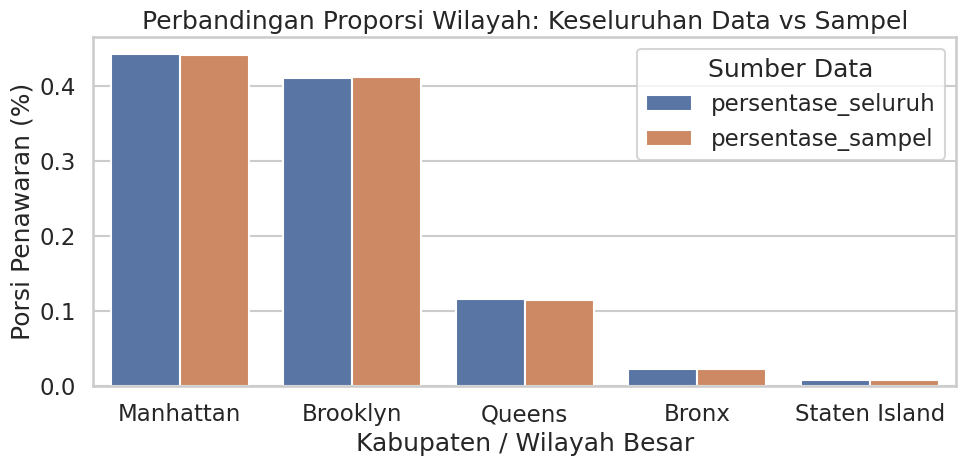

**Interpretasi :**
- Kabar baik: Jarak (selisih) porsi properti antara data asli dan sampel di tingkat wilayah adalah maksimal hanya 0.17%.
- **Apa artinya?** Memotong data menjadi jumlah kecil (sampel) ini **aman** secara geografis, tidak membuat satu kabupaten dominan menghilang.
- Hal ini penting agar analisis uji coba kita tidak menyimpang dari kenyataan populasi.

In [5]:
section("Langkah 2: Memastikan Sebagian Data (Sampel) Mewakili Seluruh Populasi")

# Ambil sampel terkontrol untuk simulasi kerja skala besar
sample_frac = 0.20
sample_df = df.sample(frac=sample_frac, random_state=42)

ask_plot("Apakah sebaran kabupaten (Borough) pada sampel sama dengan aslinya?")

global_borough = df["neighbourhood_group"].value_counts(normalize=True).rename("persentase_seluruh")
sample_borough = sample_df["neighbourhood_group"].value_counts(normalize=True).rename("persentase_sampel")
borough_compare = (
    pd.concat([global_borough, sample_borough], axis=1)
    .fillna(0)
    .assign(selisih_poin=lambda x: (x["persentase_seluruh"] - x["persentase_sampel"]).abs() * 100)
    .sort_values("persentase_seluruh", ascending=False)
)

borough_display = borough_compare.copy()
borough_display[["persentase_seluruh", "persentase_sampel"]] = borough_display[["persentase_seluruh", "persentase_sampel"]] * 100
display(borough_display.round(2))

borough_plot = borough_compare.reset_index()
first_col = borough_plot.columns[0]
borough_plot = borough_plot.rename(columns={first_col: "kabupaten"})
borough_plot = borough_plot.melt(
    id_vars="kabupaten",
    value_vars=["persentase_seluruh", "persentase_sampel"],
    var_name="sumber",
    value_name="proporsi",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=borough_plot, x="kabupaten", y="proporsi", hue="sumber")
plt.title("Perbandingan Proporsi Wilayah: Keseluruhan Data vs Sampel")
plt.ylabel("Porsi Penawaran (%)")
plt.xlabel("Kabupaten / Wilayah Besar")
plt.legend(title="Sumber Data")
plt.tight_layout()
plt.show()

max_gap_borough = borough_compare["selisih_poin"].max()
explain_plot(
    [
        f"Kabar baik: Jarak (selisih) porsi properti antara data asli dan sampel di tingkat wilayah adalah maksimal hanya {fmt_num(max_gap_borough)}%.",
        "**Apa artinya?** Memotong data menjadi jumlah kecil (sampel) ini **aman** secara geografis, tidak membuat satu kabupaten dominan menghilang.",
        "Hal ini penting agar analisis uji coba kita tidak menyimpang dari kenyataan populasi.",
    ]
)

**Pertanyaan grafik:** Apakah sebaran harga uang sewanya pada sampel juga mendekati harga global (aslinya)?

,kuantil,harga_global,harga_sampel,selisih_harga_absolut
0,0.10,49.0,49.0,0.0
1,0.25,69.0,69.0,0.0
2,0.50,106.0,107.0,1.0
3,0.75,175.0,176.0,1.0
4,0.90,269.0,270.0,1.0


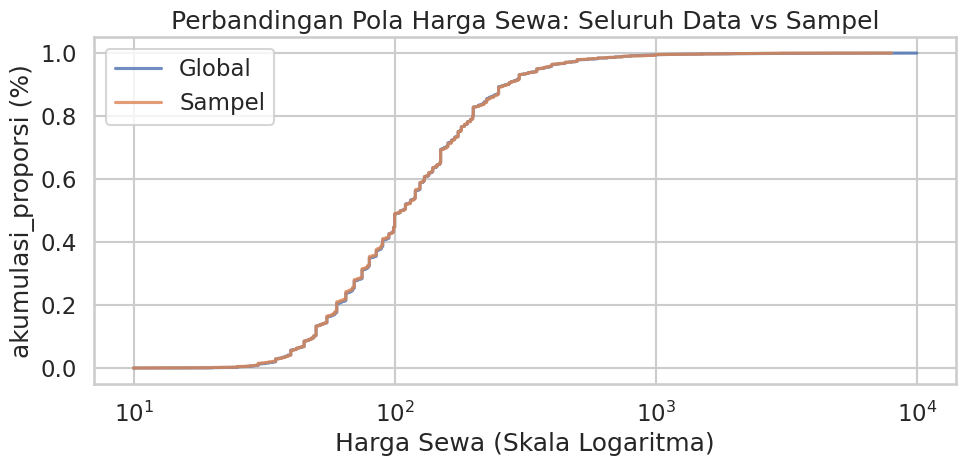

**Interpretasi :**
- Rata-rata beda harga di titik-titik pembagian kelompok harga hanya 0.60 dolar.
- Dua garis biru dan oranye pada grafik ini nyaris bertumpuk rata, ini tanda yang **sangat positif**.
- Artinya, profil harga penginapan, dari yang paling murah hingga mewah, tetap tersaji proporsional walaupun kita menggunakan hanya sedikit (sampel) data saja.

In [6]:
ask_plot("Apakah sebaran harga uang sewanya pada sampel juga mendekati harga global (aslinya)?")

q = [0.1, 0.25, 0.5, 0.75, 0.9]
price_comp = pd.DataFrame(
    {
        "kuantil": q,
        "harga_global": df["price"].quantile(q).values,
        "harga_sampel": sample_df["price"].quantile(q).values,
    }
)
price_comp["selisih_harga_absolut"] = (price_comp["harga_global"] - price_comp["harga_sampel"]).abs()
display(price_comp)

plt.figure(figsize=(10, 5))
for dset, label in [(df, "Global"), (sample_df, "Sampel")]:
    x = np.sort(dset["price"].values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label, alpha=0.8)
plt.xscale("log")
plt.title("Perbandingan Pola Harga Sewa: Seluruh Data vs Sampel")
plt.xlabel("Harga Sewa (Skala Logaritma)")
plt.ylabel("akumulasi_proporsi (%)")
plt.legend()
plt.tight_layout()
plt.show()

mean_abs_gap_quantile = price_comp["selisih_harga_absolut"].mean()
explain_plot(
    [
        f"Rata-rata beda harga di titik-titik pembagian kelompok harga hanya {fmt_num(mean_abs_gap_quantile)} dolar.",
        "Dua garis biru dan oranye pada grafik ini nyaris bertumpuk rata, ini tanda yang **sangat positif**.",
        "Artinya, profil harga penginapan, dari yang paling murah hingga mewah, tetap tersaji proporsional walaupun kita menggunakan hanya sedikit (sampel) data saja.",
    ]
)

## Langkah 3: Karakteristik Indikator Bisnis Utama (Harga & Sewa)

**Pertanyaan grafik:** Apa kelas tarif terbanyak, apakah didominasi harga 'murah' atau 'wah'?

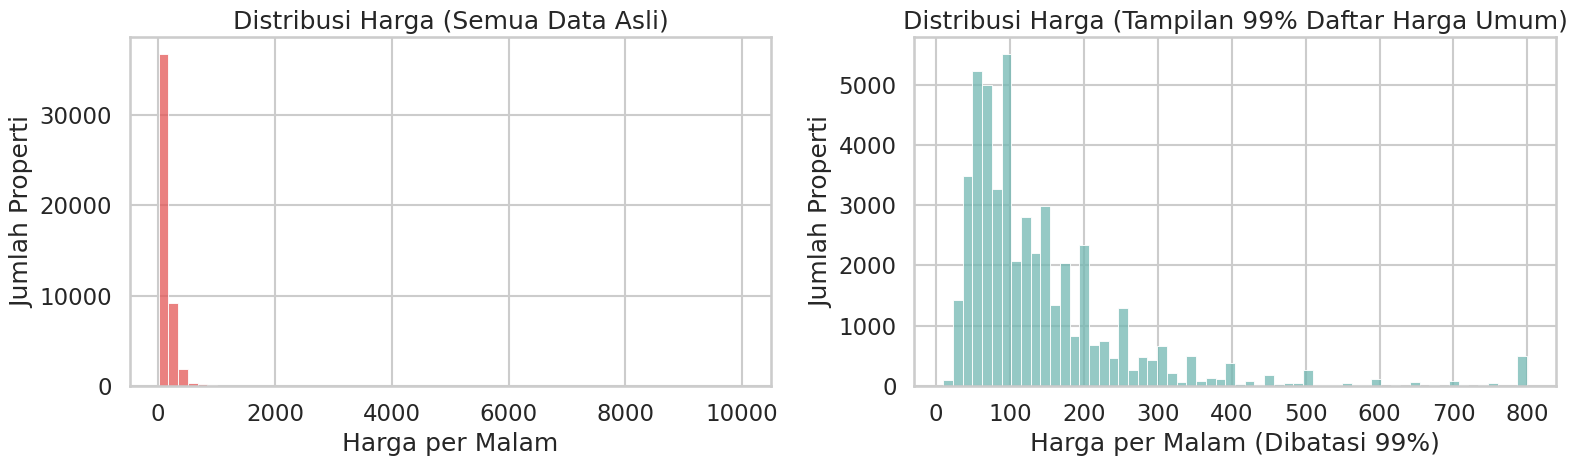

**Interpretasi :**
- Separuh keseluruhan penyewa menawarkan harga malamnya **di bawah atau sama dengan 106.00 dolar**.
- Lalu, rata-rata harganya tampak ditarik sangat melompat ke **152.76 dolar**. **Mengapa bisa?** Karena ada properti sultan yang ditawarkan 269.00 dolar sangat mahal ke atas yang menaikkan rata-rata itu secara keseluruhan.
- Saran: Pakailah angka tengah (**nilai tipikal 50% data terbawah**), karena rata-rata dapat 'berbohong' jika digabungkan bersama properti elit yang jumlahnya sedikit.

In [7]:
section("Langkah 3: Karakteristik Indikator Bisnis Utama (Harga & Sewa)")

# Versi data untuk visual yang sensitif outlier
price_hi = df["price"].quantile(0.99)
min_nights_hi = df["minimum_nights"].quantile(0.99)

df_vis = df.copy()
df_vis["price_capped"] = df_vis["price"].clip(upper=price_hi)
df_vis["minimum_nights_capped"] = df_vis["minimum_nights"].clip(upper=min_nights_hi)

ask_plot("Apa kelas tarif terbanyak, apakah didominasi harga 'murah' atau 'wah'?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["price"], bins=60, ax=ax[0], color="#E45756")
ax[0].set_title("Distribusi Harga (Semua Data Asli)")
ax[0].set_xlabel("Harga per Malam")
ax[0].set_ylabel("Jumlah Properti")

sns.histplot(df_vis["price_capped"], bins=60, ax=ax[1], color="#72B7B2")
ax[1].set_title("Distribusi Harga (Tampilan 99% Daftar Harga Umum)")
ax[1].set_xlabel("Harga per Malam (Dibatasi 99%)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

median_price = df["price"].median()
mean_price = df["price"].mean()
q90_price = df["price"].quantile(0.90)

explain_plot(
    [
        f"Separuh keseluruhan penyewa menawarkan harga malamnya **di bawah atau sama dengan {fmt_num(median_price)} dolar**.",
        f"Lalu, rata-rata harganya tampak ditarik sangat melompat ke **{fmt_num(mean_price)} dolar**. **Mengapa bisa?** Karena ada properti sultan yang ditawarkan {fmt_num(q90_price)} dolar sangat mahal ke atas yang menaikkan rata-rata itu secara keseluruhan.",
        "Saran: Pakailah angka tengah (**nilai tipikal 50% data terbawah**), karena rata-rata dapat 'berbohong' jika digabungkan bersama properti elit yang jumlahnya sedikit.",
    ]
)

**Pertanyaan grafik:** Apa syarat sewa menginap terumum (minimum malam)? Apakah lebih sering disewa musiman atau jangka panjang?

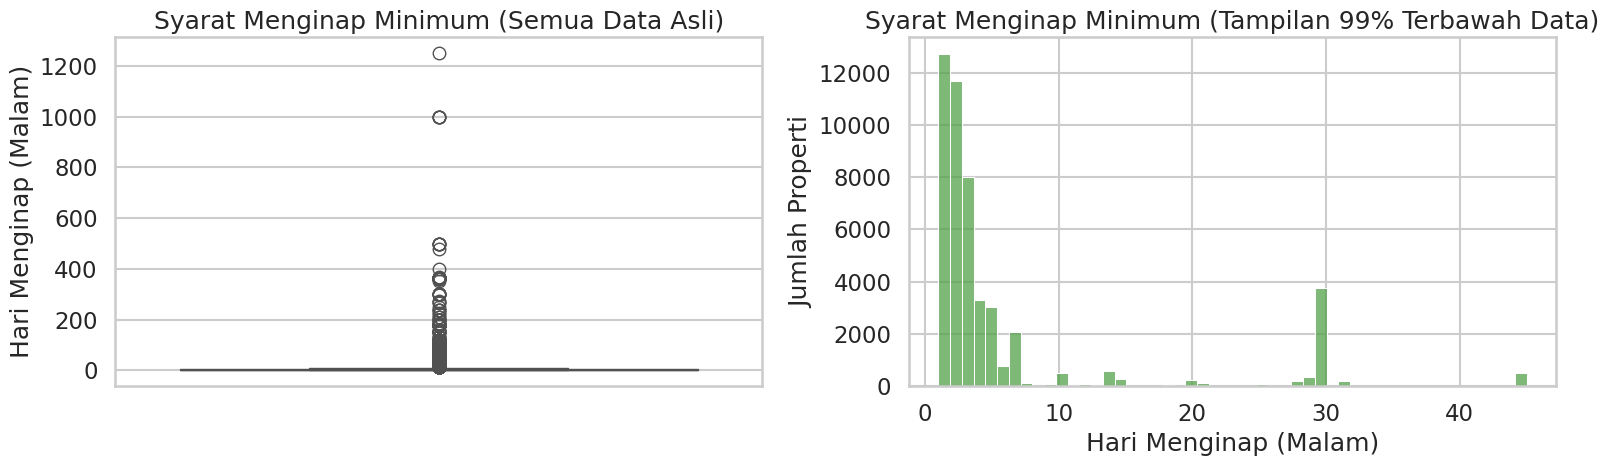

**Interpretasi :**
- Separuh keseluruhan daftar di platform ini mewajibkan minimum pesanan **3.00 malam** saja (tipe pelancong singgah/kunjungan singkat).
- Namun, ada batasan minoritas elit sebesar **28.00 malam**. Sebagian kecil peminat sewa ini beroperasi bulanan atau menetap agak lama, lebih ke indekos ketimbang model hotel harian.
- Saran: Bagilah dua model operasi bisnis: pasar penginapan pelancong akhir pekan (jangka pendek) dan pasar sewa panjang.

In [8]:
ask_plot("Apa syarat sewa menginap terumum (minimum malam)? Apakah lebih sering disewa musiman atau jangka panjang?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(y=df["minimum_nights"], ax=ax[0], color="#F58518")
ax[0].set_title("Syarat Menginap Minimum (Semua Data Asli)")
ax[0].set_ylabel("Hari Menginap (Malam)")

sns.histplot(df_vis["minimum_nights_capped"], bins=50, ax=ax[1], color="#54A24B")
ax[1].set_title("Syarat Menginap Minimum (Tampilan 99% Terbawah Data)")
ax[1].set_xlabel("Hari Menginap (Malam)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

median_min_nights = df["minimum_nights"].median()
q90_min_nights = df["minimum_nights"].quantile(0.90)

explain_plot(
    [
        f"Separuh keseluruhan daftar di platform ini mewajibkan minimum pesanan **{fmt_num(median_min_nights)} malam** saja (tipe pelancong singgah/kunjungan singkat).",
        f"Namun, ada batasan minoritas elit sebesar **{fmt_num(q90_min_nights)} malam**. Sebagian kecil peminat sewa ini beroperasi bulanan atau menetap agak lama, lebih ke indekos ketimbang model hotel harian.",
        "Saran: Bagilah dua model operasi bisnis: pasar penginapan pelancong akhir pekan (jangka pendek) dan pasar sewa panjang.",
    ]
)

**Pertanyaan grafik:** Berapa skor laris manis properti ini berdasarkan minat sewa pengunjungnya dan waktu ketersediaannya?

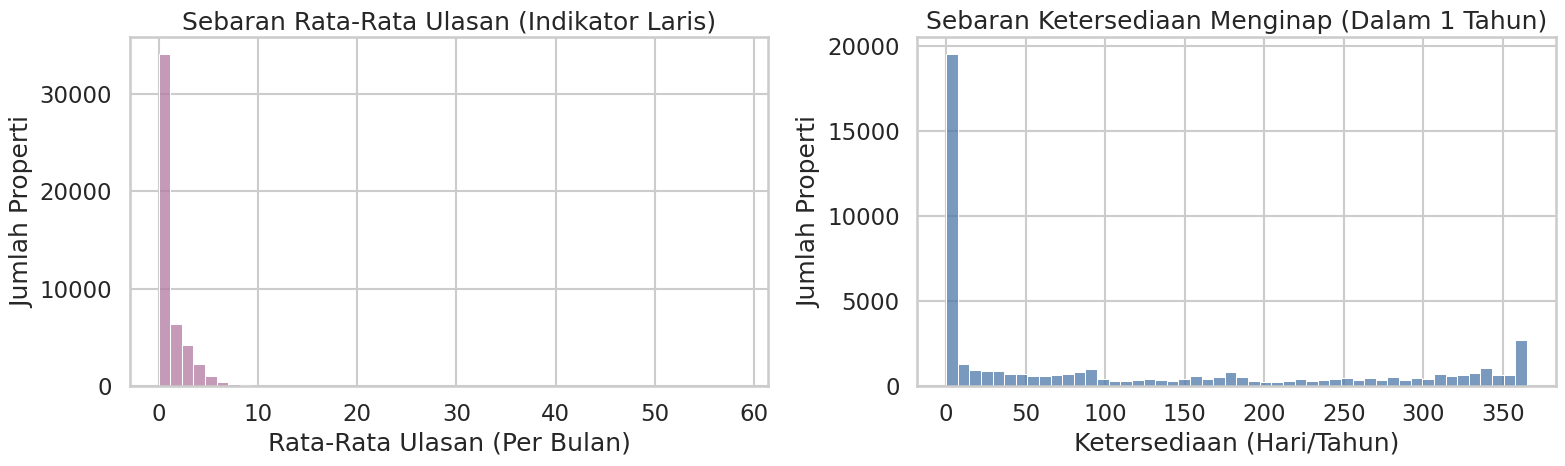

**Interpretasi :**
- Separuh keseluruhan daftar di wilayah ini mendapat ulasan baru **0.37 kali per bulan**. 
- Ketersediaan (slot sewa yang tersisa di pasar) rata-rata adalah **45.00 hari**. Semakin jarang ia kosong, maka minat pasarnya kemungkinan besar **sangat-sangat tinggi** per harinya.
- Mengapa pakai Ulasan + Ketersediaan? **Ulasan adalah tingkat pembuktian pasar.** Sedangkan **ketersediaan nol bisa jadi dua hal**: benar-benar habis terbeli tiap hari, atau statusnya ditutup pemilik bisnis. Kombinasi ini penting.

In [9]:
ask_plot("Berapa skor laris manis properti ini berdasarkan minat sewa pengunjungnya dan waktu ketersediaannya?")
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["reviews_per_month"].fillna(0), bins=50, ax=ax[0], color="#B279A2")
ax[0].set_title("Sebaran Rata-Rata Ulasan (Indikator Laris)")
ax[0].set_xlabel("Rata-Rata Ulasan (Per Bulan)")
ax[0].set_ylabel("Jumlah Properti")

sns.histplot(df["availability_365"], bins=50, ax=ax[1], color="#4C78A8")
ax[1].set_title("Sebaran Ketersediaan Menginap (Dalam 1 Tahun)")
ax[1].set_xlabel("Ketersediaan (Hari/Tahun)")
ax[1].set_ylabel("Jumlah Properti")

plt.tight_layout()
plt.show()

median_rpm = df["reviews_per_month"].fillna(0).median()
median_avail = df["availability_365"].median()

explain_plot(
    [
        f"Separuh keseluruhan daftar di wilayah ini mendapat ulasan baru **{fmt_num(median_rpm)} kali per bulan**. ",
        f"Ketersediaan (slot sewa yang tersisa di pasar) rata-rata adalah **{fmt_num(median_avail)} hari**. Semakin jarang ia kosong, maka minat pasarnya kemungkinan besar **sangat-sangat tinggi** per harinya.",
        "Mengapa pakai Ulasan + Ketersediaan? **Ulasan adalah tingkat pembuktian pasar.** Sedangkan **ketersediaan nol bisa jadi dua hal**: benar-benar habis terbeli tiap hari, atau statusnya ditutup pemilik bisnis. Kombinasi ini penting.",
    ]
)

## Langkah 4: Membaca Pasar Berdasarkan Tipe Properti & Kabupatennnya

**Pertanyaan grafik:** Apa kelas tarif sewa termahal berdasarkan wilayah atau tipe kamarnya (rumah utuh vs indekos)?

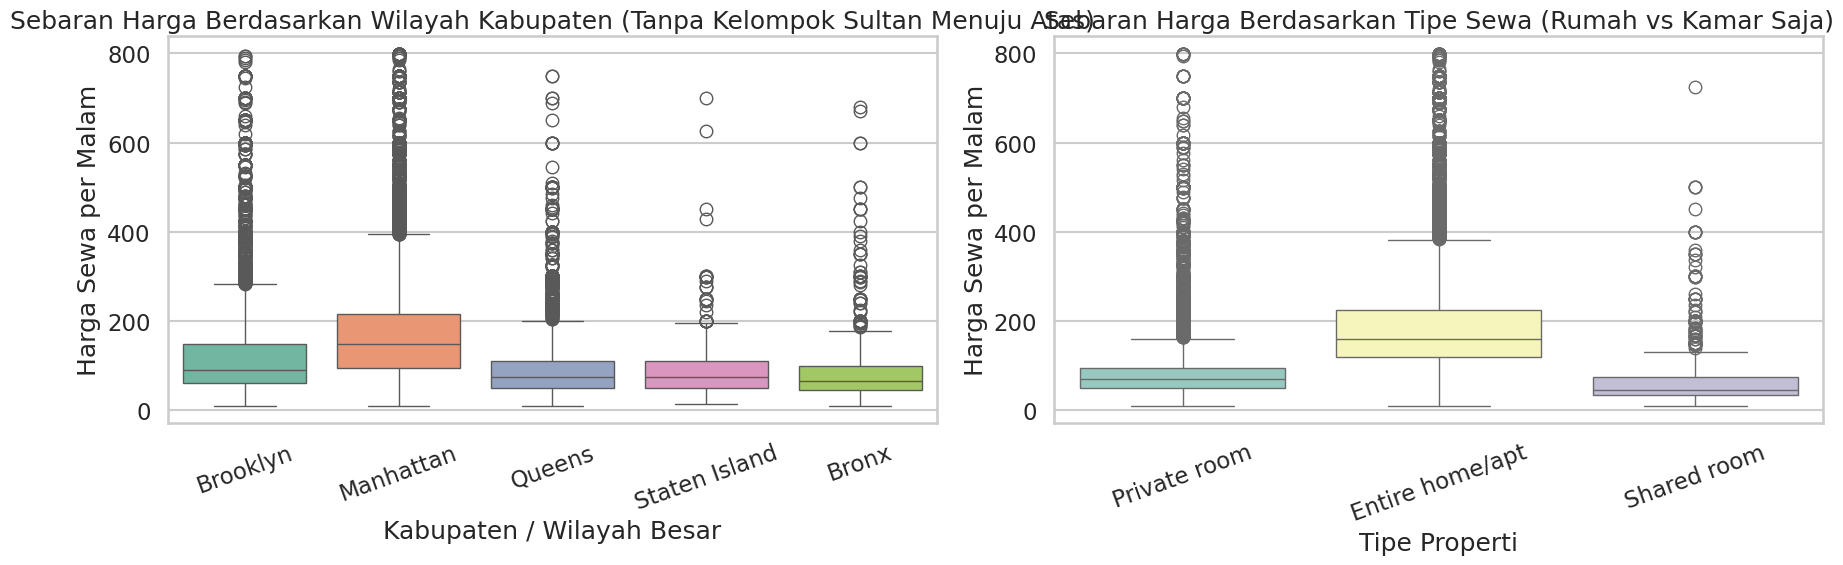

,neighbourhood_group,room_type,harga_nilai_tengah
6,Manhattan,Entire home/apt,191.0
3,Brooklyn,Entire home/apt,145.0
9,Queens,Entire home/apt,120.0
12,Staten Island,Entire home/apt,100.0
0,Bronx,Entire home/apt,100.0
7,Manhattan,Private room,90.0
8,Manhattan,Shared room,69.0
4,Brooklyn,Private room,65.0
10,Queens,Private room,60.0
1,Bronx,Private room,54.0


**Interpretasi :**
- Tipe pesanan yang selalu dihargai pasaran tertinggi jatuh di **Manhattan - Entire home/apt** (bernilai separuhnya di atas 191.00 dolar).
- Sedangkan opsi terjangkau jatuh pada daerah pinggiran di **Staten Island - Shared room** (hanya sekitar 30.00 dolar).
- Pemandangan seperti ini menegaskan **jika kita hanya mematok harga yang sama antar kota yang miskin vs kota metropolitan elit, bisa gagal fatal (kemahalan di satu titik atau dirugikan akibat terlalu murah di sisi lainnya).**

In [10]:
section("Langkah 4: Membaca Pasar Berdasarkan Tipe Properti & Kabupatennnya")

ask_plot("Apa kelas tarif sewa termahal berdasarkan wilayah atau tipe kamarnya (rumah utuh vs indekos)?")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="neighbourhood_group",
    y="price",
    ax=ax[0],
    palette="Set2",
)
ax[0].set_title("Sebaran Harga Berdasarkan Wilayah Kabupaten (Tanpa Kelompok Sultan Menuju Atas)")
ax[0].set_xlabel("Kabupaten / Wilayah Besar")
ax[0].set_ylabel("Harga Sewa per Malam")
ax[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=df_vis[df_vis["price"] <= price_hi],
    x="room_type",
    y="price",
    ax=ax[1],
    palette="Set3",
)
ax[1].set_title("Sebaran Harga Berdasarkan Tipe Sewa (Rumah vs Kamar Saja)")
ax[1].set_xlabel("Tipe Properti")
ax[1].set_ylabel("Harga Sewa per Malam")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

price_segment = (
    df.groupby(["neighbourhood_group", "room_type"])["price"]
    .median()
    .rename("harga_nilai_tengah")
    .reset_index()
    .sort_values("harga_nilai_tengah", ascending=False)
)
display(price_segment.head(10))

highest_segment = price_segment.iloc[0]
lowest_segment = price_segment.iloc[-1]

explain_plot(
    [
        (
            "Tipe pesanan yang selalu dihargai pasaran tertinggi jatuh di "
            f"**{highest_segment['neighbourhood_group']} - {highest_segment['room_type']}** "
            f"(bernilai separuhnya di atas {fmt_num(highest_segment['harga_nilai_tengah'])} dolar)."
        ),
        (
            "Sedangkan opsi terjangkau jatuh pada daerah pinggiran di "
            f"**{lowest_segment['neighbourhood_group']} - {lowest_segment['room_type']}** "
            f"(hanya sekitar {fmt_num(lowest_segment['harga_nilai_tengah'])} dolar)."
        ),
        "Pemandangan seperti ini menegaskan **jika kita hanya mematok harga yang sama antar kota yang miskin vs kota metropolitan elit, bisa gagal fatal (kemahalan di satu titik atau dirugikan akibat terlalu murah di sisi lainnya).**",
    ]
)

**Pertanyaan grafik:** Kawasan (kelurahan) manakah pusat penyumbang properti terbesar?

,jumlah_penginapan,harga_nilai_tengah
neighbourhood,,
Astoria,900,85.0
Lower East Side,911,139.0
Chelsea,1113,199.0
Greenpoint,1114,119.0
East Harlem,1117,99.0
Midtown,1545,210.0
Crown Heights,1564,85.0
Upper East Side,1798,149.0
East Village,1853,150.0


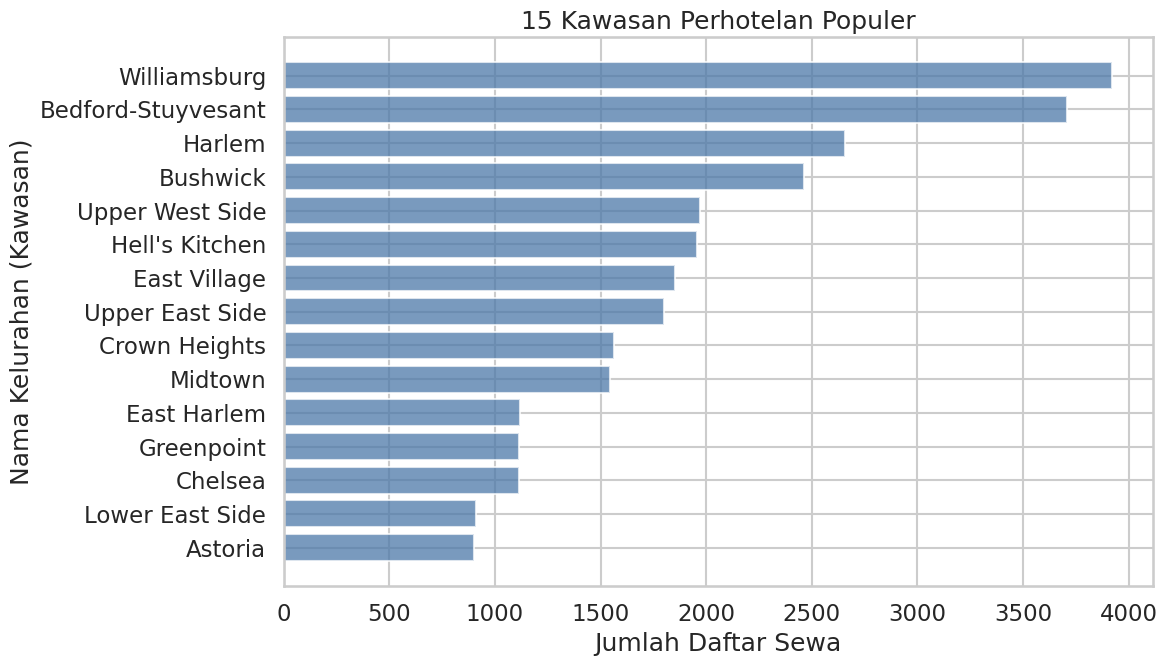

**Interpretasi :**
- Kelurahan terbanyak ini merupakan pusat tarikan di kota ini (mungkin turis paling ramai mencari area ini).
- Kalau ingin membuka investasi sewa kamar baru, masukilah pasar yang jumlahnya besar tetapi harganya tinggi menengah (lokasi premium). Atau, jika dananya tipis, cari yang harganya di bawah tengah namun volumenya meriah.
- Dari tabel nilai tengahnya (melihat murah vs mahal dari daftar paling tinggi di baris kelurahan), kita bisa melihat area metropolitan premium, berlawanan dengan spot indekos pelajar murah meriah yang sepi fasilitas elit.

In [11]:
ask_plot("Kawasan (kelurahan) manakah pusat penyumbang properti terbesar?")

top_n = 15
top_neigh_count = df["neighbourhood"].value_counts().head(top_n)

top_neigh_price = (
    df[df["neighbourhood"].isin(top_neigh_count.index)]
    .groupby("neighbourhood")["price"]
    .median()
)

neigh_tbl = pd.DataFrame(
    {
        "jumlah_penginapan": top_neigh_count,
        "harga_nilai_tengah": top_neigh_price,
    }
).sort_values("jumlah_penginapan", ascending=True)

display(neigh_tbl)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.barh(neigh_tbl.index, neigh_tbl["jumlah_penginapan"], color="#4C78A8", alpha=0.75)
ax1.set_xlabel("Jumlah Daftar Sewa")
ax1.set_ylabel("Nama Kelurahan (Kawasan)")
ax1.set_title("15 Kawasan Perhotelan Populer")
plt.tight_layout()
plt.show()

explain_plot(
    [
        "Kelurahan terbanyak ini merupakan pusat tarikan di kota ini (mungkin turis paling ramai mencari area ini).",
        "Kalau ingin membuka investasi sewa kamar baru, masukilah pasar yang jumlahnya besar tetapi harganya tinggi menengah (lokasi premium). Atau, jika dananya tipis, cari yang harganya di bawah tengah namun volumenya meriah.",
        "Dari tabel nilai tengahnya (melihat murah vs mahal dari daftar paling tinggi di baris kelurahan), kita bisa melihat area metropolitan premium, berlawanan dengan spot indekos pelajar murah meriah yang sepi fasilitas elit.",
    ]
)

## Langkah 5: Mengobservasi Juragan/Pemilik Properti (Host)

**Pertanyaan grafik:** Adakah monopoli di pasar ini (Juragan besar mendominasi properti melawan jutaan pemilik kecil)?

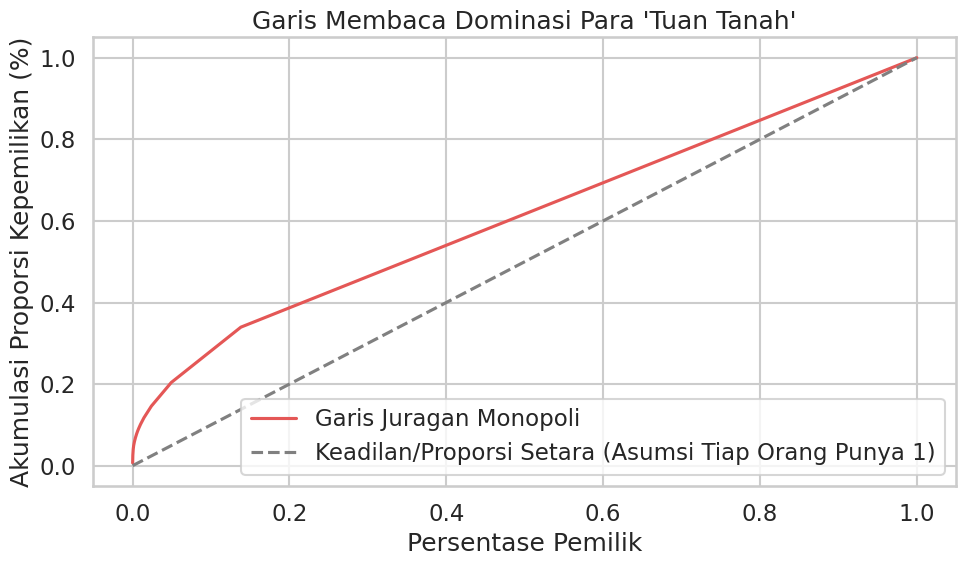

**Interpretasi :**
- Kesan bisnisnya dikerjakan oleh mayoritas jutawan terbilang tidak separah persepsi kita. Walau memang 10.10% bisnis ini dimiliki oleh 1% elit tuan tanah, garis merah dan abu-nya tidak terlampau mengerikan seperti tebing vertikal.
- Ini artinya, kalau tuan tanah raksasa ini kabur, propertinya mungkin runtuh sebagian (sekitar lebih dari sepuluh hingga seperempat penguasaan pasar), tetapi industri ini sangat bisa bernafas sehat.
- Satu juragan bisa membawa puluhan kamar (biasanya agensi pengelola, atau apartemen grup). Mereka menetapkan harga kompetitif, jadi **pemilik dengan modal 1 apartemen saja pun harus pintar bermain di harga pasar kelompok kecil.**

In [12]:
section("Langkah 5: Mengobservasi Juragan/Pemilik Properti (Host)")

ask_plot("Adakah monopoli di pasar ini (Juragan besar mendominasi properti melawan jutaan pemilik kecil)?")
host_counts = df.groupby("host_id").size().rename("jumlah_properti").sort_values(ascending=False)

host_share = host_counts / host_counts.sum()
cum_host = np.arange(1, len(host_share) + 1) / len(host_share)
cum_listing = host_share.cumsum().values

plt.figure(figsize=(10, 6))
plt.plot(cum_host, cum_listing, label="Garis Juragan Monopoli", color="#E45756")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Keadilan/Proporsi Setara (Asumsi Tiap Orang Punya 1)")
plt.title("Garis Membaca Dominasi Para 'Tuan Tanah'")
plt.xlabel("Persentase Pemilik")
plt.ylabel("Akumulasi Proporsi Kepemilikan (%)")
plt.legend()
plt.tight_layout()
plt.show()

top_1pct = max(1, int(len(host_counts) * 0.01))
share_top_1pct = host_counts.head(top_1pct).sum() / host_counts.sum() * 100

explain_plot(
    [
        f"Kesan bisnisnya dikerjakan oleh mayoritas jutawan terbilang tidak separah persepsi kita. Walau memang {fmt_num(share_top_1pct)}% bisnis ini dimiliki oleh 1% elit tuan tanah, garis merah dan abu-nya tidak terlampau mengerikan seperti tebing vertikal.",
        "Ini artinya, kalau tuan tanah raksasa ini kabur, propertinya mungkin runtuh sebagian (sekitar lebih dari sepuluh hingga seperempat penguasaan pasar), tetapi industri ini sangat bisa bernafas sehat.",
        "Satu juragan bisa membawa puluhan kamar (biasanya agensi pengelola, atau apartemen grup). Mereka menetapkan harga kompetitif, jadi **pemilik dengan modal 1 apartemen saja pun harus pintar bermain di harga pasar kelompok kecil.**",
    ]
)

**Pertanyaan grafik:** Apa kecenderungan kamar laku dengan kamar kosong (kosong melompong vs habis total)?

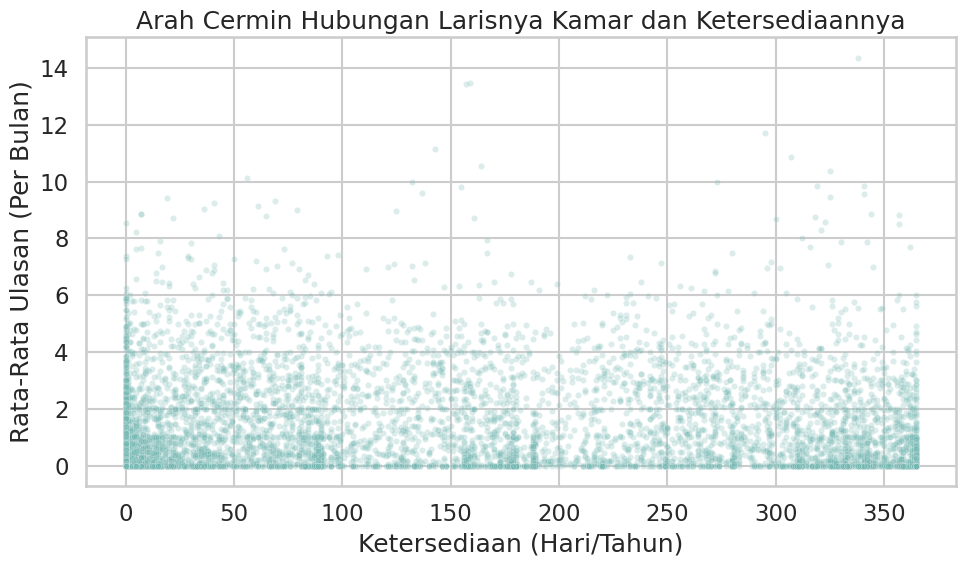

**Interpretasi :**
- Kecenderungan angka arah hubungannya (yang bisa membuktikan seiring sejalan (+1), bertolak belakang (-1), atau putus acak (0)) berada di angka: **0.16**.
- Nilai hubungan arah ke atas (positif). Semakin lapang kosongnya, ulasan justru nambah tipis (aneh, ya?). Kemungkinannya, ia rumah super sibuk gonta-ganti kamar (disewanya juga cuman mampir singkat bulanan penuh).
- Tapi angka ini sangat rendah. Artinya ini seperti melihat **bintang bertaburan lebat**. Keputusan Anda sama sekali tidak aman jika sekedar melabraknya secara korelasi rumus linier, sebab ini bukan ukuran sebab-akibat tunggal (peminangan dipengaruhi area geografis dan tarif perkamarnya juga).

In [13]:
ask_plot("Apa kecenderungan kamar laku dengan kamar kosong (kosong melompong vs habis total)?")
scatter_df = df[["availability_365", "reviews_per_month"]].copy()
scatter_df["reviews_per_month"] = scatter_df["reviews_per_month"].fillna(0)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_df.sample(min(10000, len(scatter_df)), random_state=42),
    x="availability_365",
    y="reviews_per_month",
    alpha=0.25,
    s=20,
    color="#72B7B2",
)
plt.title("Arah Cermin Hubungan Larisnya Kamar dan Ketersediaannya")
plt.xlabel("Ketersediaan (Hari/Tahun)")
plt.ylabel("Rata-Rata Ulasan (Per Bulan)")
plt.tight_layout()
plt.show()

corr_avail_rpm = scatter_df["availability_365"].corr(scatter_df["reviews_per_month"])
if corr_avail_rpm > 0:
    hubungan_teks = "Nilai hubungan arah ke atas (positif). Semakin lapang kosongnya, ulasan justru nambah tipis (aneh, ya?). Kemungkinannya, ia rumah super sibuk gonta-ganti kamar (disewanya juga cuman mampir singkat bulanan penuh)."
elif corr_avail_rpm < 0:
    hubungan_teks = "Nilai hubungannya berlawanan arah (negatif). Kalau ulasan meledak ramai, rataan harinya otomatis seret/kosong nol koma. Ini masuk akal (terlalu membludak dipesan sehingga 0 sisa kosong di pasaran!)."
else:
    hubungan_teks = "Arahnya datar tanpa makna arah (angka mendekati nol). Artinya laris-tidaknya sama sekali tidak mencerminkan properti sering di-kalender kosong atau terbuka sepanjang tahun. Bisa dipesan, siap dilibas, dan tidak berarti laku keras atau hancur."

explain_plot(
    [
        f"Kecenderungan angka arah hubungannya (yang bisa membuktikan seiring sejalan (+1), bertolak belakang (-1), atau putus acak (0)) berada di angka: **{fmt_num(corr_avail_rpm)}**.",
        hubungan_teks,
        "Tapi angka ini sangat rendah. Artinya ini seperti melihat **bintang bertaburan lebat**. Keputusan Anda sama sekali tidak aman jika sekedar melabraknya secara korelasi rumus linier, sebab ini bukan ukuran sebab-akibat tunggal (peminangan dipengaruhi area geografis dan tarif perkamarnya juga).",
    ]
)

## Langkah 6: Peta Lokasi Mahal vs Murah (Pola Geografis Sesungguhnya)

**Pertanyaan grafik:** Apa rupa pengelompokan wilayah ini, harga bersahabat dan sultan menumpuk di mana?

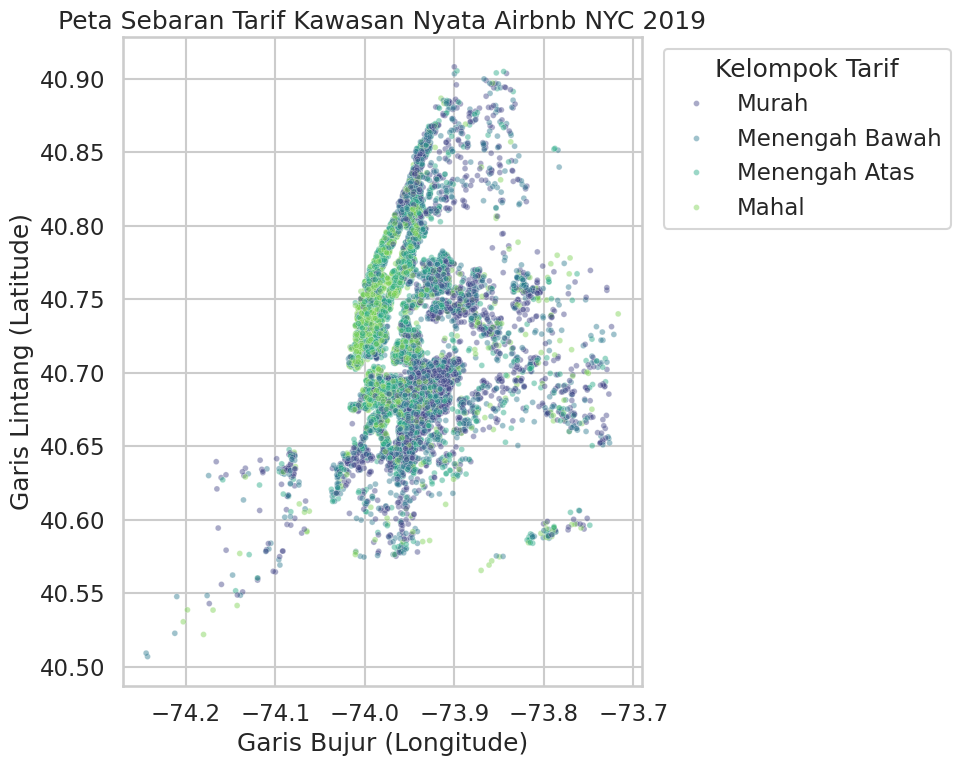

,harga_tengah_wilayah
neighbourhood_group,
Manhattan,150.0
Brooklyn,90.0
Queens,75.0
Staten Island,75.0
Bronx,65.0


**Interpretasi :**
- Perpaduan warna sebaran pulau ini menunjukkan titik hijau-kuning cerah (Harga Sultan/Mahal) memeluk satu titik utama di pusarannya (tentu, *Manhattan*).
- Warna biru sampai ungu gelap (Harga Rakyat), membentang jauh meluber ke luar jembatan.
- Lalu jika mau sukses menyewa pinggiran? Bisa! Pasarkan sewa properti ke warna gelap itu tapi jangan halu mematok harga gaya Manhattan karena anda harus merendahkan harganya. Sebaliknya, wilayah elit yang menyewakan murahan berarti **buang-buang cuan!**

In [14]:
section("Langkah 6: Peta Lokasi Mahal vs Murah (Pola Geografis Sesungguhnya)")

ask_plot("Apa rupa pengelompokan wilayah ini, harga bersahabat dan sultan menumpuk di mana?")

map_df = df.copy()
map_df["kelompok_tarif"] = pd.qcut(
    map_df["price"].rank(method="first"),
    q=4,
    labels=["Murah", "Menengah Bawah", "Menengah Atas", "Mahal"],
)

plot_map = map_df.sample(min(15000, len(map_df)), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_map,
    x="longitude",
    y="latitude",
    hue="kelompok_tarif",
    alpha=0.45,
    s=18,
    palette="viridis",
)
plt.title("Peta Sebaran Tarif Kawasan Nyata Airbnb NYC 2019")
plt.xlabel("Garis Bujur (Longitude)")
plt.ylabel("Garis Lintang (Latitude)")
plt.legend(title="Kelompok Tarif", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

price_by_borough = df.groupby("neighbourhood_group")["price"].median().sort_values(ascending=False)
display(price_by_borough.to_frame("harga_tengah_wilayah"))

explain_plot(
    [
        "Perpaduan warna sebaran pulau ini menunjukkan titik hijau-kuning cerah (Harga Sultan/Mahal) memeluk satu titik utama di pusarannya (tentu, *Manhattan*).",
        "Warna biru sampai ungu gelap (Harga Rakyat), membentang jauh meluber ke luar jembatan.",
        "Lalu jika mau sukses menyewa pinggiran? Bisa! Pasarkan sewa properti ke warna gelap itu tapi jangan halu mematok harga gaya Manhattan karena anda harus merendahkan harganya. Sebaliknya, wilayah elit yang menyewakan murahan berarti **buang-buang cuan!**",
    ]
)

In [ ]:
section("Langkah 7: Meringkas Data")

# Contoh agregasi bertahap: tahap 1 (rincian kecil), tahap 2 (gabungan besar)
stage_1 = (
    df.groupby(["neighbourhood_group", "room_type"], as_index=False)
    .agg(
        jumlah_penginapan=("id", "count"),
        rata_nilai_tengah_sewa=("price", "median"),
        skor_ulasan_laku_rata_rata=("reviews_per_month", "mean"),
    )
)

stage_2 = (
    stage_1.groupby("neighbourhood_group", as_index=False)
    .agg(
        total_kamar_kabupaten=("jumlah_penginapan", "sum"),
        skor_nilai_tengah_seluruh_sewa=("rata_nilai_tengah_sewa", "median"),
        skor_terlaku_seluruh_kabupaten=("skor_ulasan_laku_rata_rata", "mean"),
    )
    .sort_values("total_kamar_kabupaten", ascending=False)
)

display(Markdown("### Ringkasan Tahap 1 (Wilayah Besar x Tipe Kamar)"))
display(stage_1)

display(Markdown("### Ringkasan Tahap 2 (Dikumpulkan Penuh ke Level Kabupaten)"))
display(stage_2)

## Langkah 7: Meringkas Data Bertahap agar Komputer Tidak Lemot / Hang

### Ringkasan Tahap 1 (Wilayah Besar x Tipe Kamar)

,neighbourhood_group,room_type,jumlah_penginapan,rata_nilai_tengah_sewa,skor_ulasan_laku_rata_rata
0,Bronx,Entire home/apt,379,100.0,2.238123
1,Bronx,Private room,651,54.0,1.639904
2,Bronx,Shared room,60,40.0,1.351860
3,Brooklyn,Entire home/apt,9558,145.0,1.317773
4,Brooklyn,Private room,10126,65.0,1.254912
5,Brooklyn,Shared room,411,36.0,1.077118
6,Manhattan,Entire home/apt,13198,191.0,1.141610
7,Manhattan,Private room,7982,90.0,1.448949
8,Manhattan,Shared room,480,69.0,1.792781
9,Queens,Entire home/apt,2096,120.0,1.967302


### Ringkasan Tahap 2 (Dikumpulkan Penuh ke Level Kabupaten)

,neighbourhood_group,total_kamar_kabupaten,skor_nilai_tengah_seluruh_sewa,skor_terlaku_seluruh_kabupaten
2,Manhattan,21660,90.0,1.461113
1,Brooklyn,20095,65.0,1.216601
3,Queens,5666,60.0,1.812719
0,Bronx,1090,54.0,1.743296
4,Staten Island,373,50.0,1.701861
